In [1]:
import pandas as pd
df = pd.read_csv("data/processed/sales_cleaned.csv")

In [2]:
df["Revenue"] = df["Price"] * df["Units Sold"]

In [3]:
df["adjusted_price"] = df["Price"] * 1.05

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["day_of_week"] = df["Date"].dt.day_name()

In [5]:
df.loc[df["day_of_week"].isin(["Saturday", "Sunday"]), "adjusted_Price"] *= 1.10

KeyError: 'adjusted_Price'

In [ ]:
df.loc[df["Inventory Level"] < 20, "adjusted_Price"] *= 1.15
df.loc[df["Inventory Level"] > 100, "adjusted_Price"] *= 0.90

In [ ]:
df.loc[df["Units Sold"] > 50, "adjusted_Price"] *= 1.05

In [ ]:
df["new_Revenue"] = df["adjusted_Price"] * df["Units Sold"]

In [ ]:
def adjust_price(row):

    price = row["Price"]

    if row["Units Sold"] > 50:   # high demand
        price = price * 1.10

    elif row["Units Sold"] < 20: # low demand
        price = price * 0.97

    return price

df["adjusted_Price"] = df.apply(adjust_price, axis=1)

In [ ]:
original_total = df["Revenue"].sum()
new_total = df["new_Revenue"].sum()

revenue_lift = ((new_total - original_total) / original_total) * 100

print("Original Revenue:", original_total)
print("New Revenue:", new_total)
print("Revenue Lift (%):", revenue_lift)

Original Revenue: 455300094.5
New Revenue: 466935268.56430656
Revenue Lift (%): 2.5554956400973374


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Original Revenue", "Dynamic Revenue", "Revenue Lift (%)"],
    "Value": [original_total, new_total, revenue_lift]
})
comparison

,Metric,Value
0,Original Revenue,4.553001e+08
1,Dynamic Revenue,4.669353e+08
2,Revenue Lift (%),2.555496e+00


In [ ]:
df[["Price", "adjusted_Price"]].head()

,Price,adjusted_Price
0,72.72,79.992
1,80.16,88.176
2,62.94,69.234
3,87.63,87.630
4,54.41,59.851


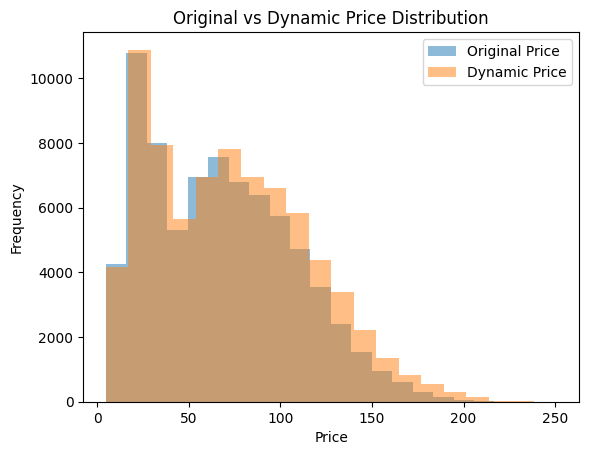

In [ ]:
import matplotlib.pyplot as plt
plt.figure()

plt.hist(df["Price"], bins=20, alpha=0.5, label="Original Price")
plt.hist(df["adjusted_Price"], bins=20, alpha=0.5, label="Dynamic Price")

plt.title("Original vs Dynamic Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()

plt.show()

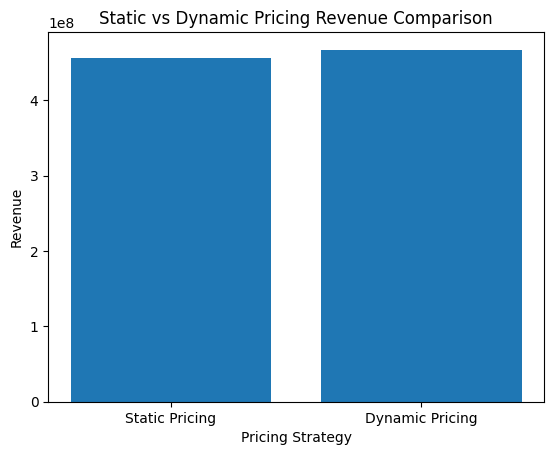

In [ ]:
import matplotlib.pyplot as plt

labels = ["Static Pricing", "Dynamic Pricing"]
values = [original_total, new_total]

plt.figure()
plt.bar(labels, values)

plt.title("Static vs Dynamic Pricing Revenue Comparison")
plt.ylabel("Revenue")
plt.xlabel("Pricing Strategy")

plt.show()